# Phase 2.3 Observability: Ingest and Embeddings

This notebook traces ingestion and embedding workflow with quick diagnostics.

Goals:
- Ingest sample documents through the API
- Inspect pipeline and vector-store status
- Validate embedding dimensions and inspect sample values
- Capture timing metrics for each step

In [15]:
import json

import os

import sys

import time

from pathlib import Path



import requests



BASE_URL = os.getenv('RAG_API_BASE_URL', 'http://127.0.0.1:8000')

REQUEST_TIMEOUT = 180

INGEST_USE_SAMPLE = os.getenv('INGEST_USE_SAMPLE', 'false').lower() in {'1', 'true', 'yes'}

INGEST_MAX_DOCS = int(os.getenv('INGEST_MAX_DOCS', '10'))

timings = {}



repo_root = Path.cwd().parent

src_path = repo_root / 'src'

if str(src_path) not in sys.path:

    sys.path.append(str(src_path))



print(f'API base URL: {BASE_URL}')

print(f'Repo root: {repo_root}')

print(f'Request timeout: {REQUEST_TIMEOUT} seconds')

print(f'Ingest config: use_sample={INGEST_USE_SAMPLE}, max_docs={INGEST_MAX_DOCS}')


API base URL: http://127.0.0.1:8000
Repo root: c:\Users\mgozzi\da_forge_march_2026\.venv\da-rag-project-2026-starter-pack-main
Request timeout: 180 seconds
Ingest config: use_sample=False, max_docs=10


In [16]:
# Startup check: fail early with a clear message if API is not running.
try:
    health = requests.get(f'{BASE_URL}/health', timeout=5)
    health.raise_for_status()
    print('Server is reachable:', health.json())
except Exception as exc:
    raise RuntimeError(
        f'API not reachable at {BASE_URL}. Start the server first, for example: '
        f'python run_server.py (from project root). Error: {exc}'
    )

Server is reachable: {'status': 'ok'}


## Step 1: Call /ingest to load documents

In [17]:
start = time.perf_counter()

resp_ingest = requests.post(

    f'{BASE_URL}/ingest',

    params={'use_sample': str(INGEST_USE_SAMPLE).lower(), 'max_docs': INGEST_MAX_DOCS},

    timeout=REQUEST_TIMEOUT,

)

resp_ingest.raise_for_status()

ingest_payload = resp_ingest.json()

timings['ingest_seconds'] = time.perf_counter() - start

ingest_payload


ReadTimeout: HTTPConnectionPool(host='127.0.0.1', port=8000): Read timed out. (read timeout=180)

## Step 2: Show loaded count and sample texts

In [11]:
status_payload = requests.get(f'{BASE_URL}/status', timeout=REQUEST_TIMEOUT).json()



sample_docs = [

    {

        'text': 'The quick brown fox jumps over the lazy dog.',

        'id': 'sample-1',

        'meta': {'source': 'local-sample'},

    },

    {

        'text': 'Python is a programming language that emphasizes readability.',

        'id': 'sample-2',

        'meta': {'source': 'local-sample'},

    },

]



print('Pipeline status:')

print(json.dumps(status_payload, indent=2))

print()

print('Sample document count:', len(sample_docs))

print('Sample texts:')

for doc in sample_docs:

    text_preview = doc['text'][:120]

    print(f"- {doc['id']}: {text_preview}")


Pipeline status:
{
  "loaded": true,
  "documents": 2,
  "embeddings_created": true,
  "embeddings_count": 2,
  "index_path": "./data/index",
  "vector_store_loaded": true,
  "vector_store_count": 2,
  "vector_store_path": "data\\vector_store.json",
  "vector_store_dimension": 3072
}

Sample document count: 2
Sample texts:
- sample-1: The quick brown fox jumps over the lazy dog.
- sample-2: Python is a programming language that emphasizes readability.


## Step 3: Call /vector-store/status for indexing results

In [12]:
start = time.perf_counter()
vector_status = requests.get(f'{BASE_URL}/vector-store/status', timeout=REQUEST_TIMEOUT)
vector_status.raise_for_status()
vector_payload = vector_status.json()
timings['vector_status_seconds'] = time.perf_counter() - start
vector_payload

{'vector_store': {'loaded': True,
  'document_count': 2,
  'dimension': 3072,
  'path': 'data\\vector_store.json'}}

## Step 4: Visualize embedding dimensions and sample vectors

Vector store dimension: 3072
Vector store document count: 2
First document id: sample-1
First 16 embedding values: [-0.012696055695414543, 0.009628890082240105, -0.011472541838884354, 0.0206488985568285, 0.0013094117166474462, -0.021486921235919, 0.010106563568115234, 0.06275119632482529, -0.01743088848888874, 0.006817320827394724, 0.0074542188085615635, 0.03898485377430916, 0.00921825785189867, -0.05309716612100601, -0.005304688587784767, 0.03724176436662674]
Embedding length: 3072


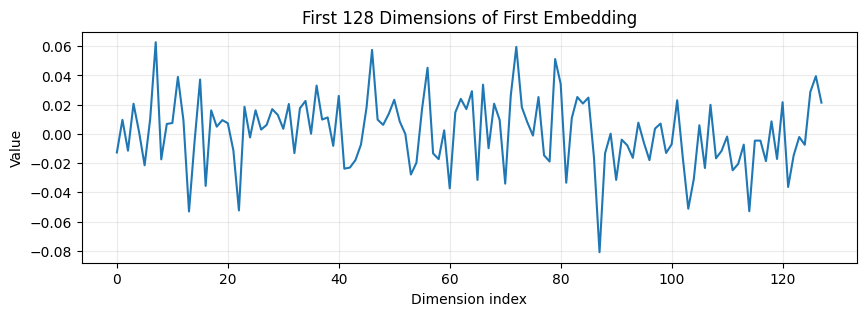

In [13]:
vector_store_path = repo_root / 'data' / 'vector_store.json'
if not vector_store_path.exists():
    raise FileNotFoundError(f'Vector store file not found: {vector_store_path}')

with open(vector_store_path, 'r', encoding='utf-8') as f:
    store_data = json.load(f)

dimension = store_data.get('dimension', 0)
document_count = store_data.get('document_count', 0)
documents = store_data.get('documents', [])

print('Vector store dimension:', dimension)
print('Vector store document count:', document_count)

if documents:
    first = documents[0]
    emb = first.get('embedding', [])
    print('First document id:', first.get('id'))
    print('First 16 embedding values:', emb[:16])
    print('Embedding length:', len(emb))
else:
    print('No documents found in vector store.')

try:
    import matplotlib.pyplot as plt

    if documents and emb:
        plt.figure(figsize=(10, 3))
        plt.plot(emb[:128])
        plt.title('First 128 Dimensions of First Embedding')
        plt.xlabel('Dimension index')
        plt.ylabel('Value')
        plt.grid(True, alpha=0.25)
        plt.show()
except Exception as exc:
    print('Matplotlib plot skipped:', exc)

## Step 5: Show timing and performance metrics

In [14]:
timings['total_seconds'] = timings.get('ingest_seconds', 0.0) + timings.get('vector_status_seconds', 0.0)

print('Timing metrics (seconds):')
for key in sorted(timings.keys()):
    print(f'- {key}: {timings[key]:.4f}')

if timings.get('ingest_seconds'):
    docs = ingest_payload.get('ingested', 0)
    print()
    print('Ingest throughput (docs/sec):', round(docs / timings['ingest_seconds'], 2) if timings['ingest_seconds'] > 0 else 'n/a')

Timing metrics (seconds):
- ingest_seconds: 14.8514
- total_seconds: 14.8593
- vector_status_seconds: 0.0078

Ingest throughput (docs/sec): 0.13
